# What is Applicability Domain (AD)?

Applicability Domain (AD) defines the chemical space in which a machine learning model can make reliable predictions.

A prediction is considered reliable only if the new molecule is sufficiently similar to the molecules used during model training.

If a molecule lies outside the applicability domain, the prediction may be unreliable because the model has never encountered similar chemistry before.|

## Why Do We Need Applicability Domain?

Machine learning models can generate predictions for almost any molecule.

However, making a prediction does not guarantee that the prediction is trustworthy.

For example, a QSAR model trained only on small organic molecules may not perform well when predicting the properties of a large peptide or a metal-containing compound.

Applicability Domain helps determine whether a prediction should be trusted.

# How do we determine the Applicability Domain?

# Distance-Based Applicability Domain

The distance-based approach determines whether a new molecule is similar enough to the molecules used during model training.

The idea is simple:

- If a new molecule is close to the training molecules in feature space, it is considered inside the Applicability Domain.
- If a new molecule is far away, it is considered outside the Applicability Domain, and its prediction may be unreliable.

The distance is calculated using the molecular feature matrix generated from descriptors and fingerprints.

# How is Distance Measured ?
## Measuring Distance

Each molecule is represented by a feature vector containing molecular descriptors and fingerprints.

The distance between molecules can be calculated using various metrics, including:

- Euclidean Distance
- Manhattan Distance
- Cosine Distance

In cheminformatics, Euclidean distance is commonly used for descriptor-based features, while Tanimoto similarity is often preferred for fingerprint-based representations.

# Example

In [1]:
# Import Libraries

import pandas as pd
import numpy as np

from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import rdFingerprintGenerator

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

In [2]:
# Load the Dataset

df = pd.read_csv("esol_raw.csv")

df = df[["smiles", "measured log solubility in mols per litre"]]

df["Mol"] = df["smiles"].apply(Chem.MolFromSmiles)

df = df[df["Mol"].notnull()]

#remove Duplicates
df = df.drop_duplicates(subset="smiles").reset_index(drop=True)

print("Number of molecules:", len(df))

Number of molecules: 1128


In [3]:
# Generate Features

descriptor_data = []

for mol in df["Mol"]:
    descriptor_data.append([
        Descriptors.MolWt(mol),
        Descriptors.MolLogP(mol),
        Descriptors.TPSA(mol),
        Descriptors.NumHDonors(mol),
        Descriptors.NumHAcceptors(mol),
        Descriptors.NumRotatableBonds(mol),
        Descriptors.RingCount(mol),
        Descriptors.HeavyAtomCount(mol),
        Descriptors.FractionCSP3(mol),
        Descriptors.NumValenceElectrons(mol)
    ])

descriptor_df = pd.DataFrame(descriptor_data)

In [5]:
# Train-Test Split

X = descriptor_df

y = df["measured log solubility in mols per litre"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(902, 10)
(226, 10)


In [6]:
# Standardize Features
# Distance calculations should be performed on scaled features.

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# Calculate the distance

In [7]:
nn = NearestNeighbors(n_neighbors=2)

nn.fit(X_train_scaled)

train_distances, _ = nn.kneighbors(X_train_scaled)

threshold = np.percentile(train_distances[:,1],95)

In [8]:
test_distances, _ = nn.kneighbors(X_test_scaled)

inside_AD = test_distances[:,0] <= threshold

In [9]:
print(f"AD Threshold: {threshold:.3f}")

AD Threshold: 1.343


In [10]:
print("Inside AD :", inside_AD.sum())
print("Outside AD:", (~inside_AD).sum())

Inside AD : 214
Outside AD: 12


In [11]:
inside = inside_AD.sum()
outside = (~inside_AD).sum()

print(f"Inside AD : {inside}")
print(f"Outside AD: {outside}")

print(f"Inside AD Percentage : {inside/len(inside_AD)*100:.2f}%")
print(f"Outside AD Percentage: {outside/len(inside_AD)*100:.2f}%")

Inside AD : 214
Outside AD: 12
Inside AD Percentage : 94.69%
Outside AD Percentage: 5.31%


# Visualization

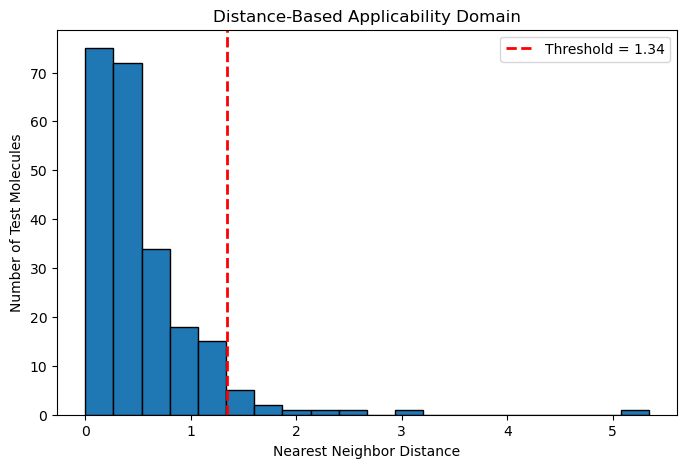

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(test_distances[:,0], bins=20, edgecolor="black")

plt.axvline(
    threshold,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Threshold = {threshold:.2f}"
)

plt.xlabel("Nearest Neighbor Distance")
plt.ylabel("Number of Test Molecules")
plt.title("Distance-Based Applicability Domain")
plt.legend()

plt.show()

In [13]:
results = pd.DataFrame({
    "Metric": [
        "Training Molecules",
        "Test Molecules",
        "AD Threshold",
        "Inside AD",
        "Outside AD",
        "Inside AD (%)",
        "Outside AD (%)"
    ],
    "Value": [
        len(X_train),
        len(X_test),
        round(threshold, 3),
        inside_AD.sum(),
        (~inside_AD).sum(),
        f"{inside_AD.mean()*100:.2f}%",
        f"{(~inside_AD).mean()*100:.2f}%"
    ]
})

results

,Metric,Value
0,Training Molecules,902
1,Test Molecules,226
2,AD Threshold,1.343
3,Inside AD,214
4,Outside AD,12
5,Inside AD (%),94.69%
6,Outside AD (%),5.31%


## Interpretation

The Applicability Domain (AD) was evaluated using the nearest-neighbor distance approach based on molecular descriptors.

A threshold of 1.343 was determined using the 95th percentile of the nearest-neighbor distances among the training molecules.

Out of 226 test molecules:

- 214 molecules (94.69%) were classified as inside the Applicability Domain, indicating that they are sufficiently similar to the training molecules and their predictions are expected to be reliable.

- 12 molecules (5.31%) were classified as outside the Applicability Domain, suggesting that these molecules are structurally different from the training data. Predictions for these molecules should therefore be interpreted with caution.

This analysis helps assess the reliability of model predictions by determining whether a new molecule lies within the chemical space covered by the training dataset.|